<a href="https://colab.research.google.com/github/Ragul2526/Cryptocurrency-Price-Prediction/blob/main/crypto_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance -q

import yfinance as yf
import pandas as pd
import os

In [2]:


def fetch_cryp(coin_symbol, yf_symbol):

  df = yf.download(yf_symbol, start = "2013-01-01", progress = False)
  df.columns = df.columns.get_level_values(0)
  df = df[["Close"]].rename(columns = {"Close": "price"})
  df.index.name = "date"
  os.makedirs("crypto", exist_ok=True)
  df.to_csv(f'crypto/{coin_symbol}.csv')
  print(f"{coin_symbol.upper()}: {len(df)} rows saved → crypto/{coin_symbol}.csv")
  return df


In [3]:
import warnings
warnings.filterwarnings("ignore") #we get a warning from yahoo finance which is not going to affect so using this to filter the warning

coins = {
    "btc": "BTC-USD",
    "eth": "ETH-USD",
    "sol": "SOL-USD",
    "xrp": "XRP-USD",
    "ltc": "LTC-USD"
}
#If you need to add more crptocurrencies go to yahoo finance and check the available currencies and add to coins as well.
dataframe = {}
for coin_symbol,yf_symbol in coins.items():
  df = fetch_cryp(coin_symbol,yf_symbol)
  if df is not None:
    dataframe[coin_symbol] = df


print("\nAll coins fetched successfully!")
print("Coins available: ",(list(dataframe.keys())))


BTC: 4284 rows saved → crypto/btc.csv
ETH: 3135 rows saved → crypto/eth.csv
SOL: 2252 rows saved → crypto/sol.csv
XRP: 3135 rows saved → crypto/xrp.csv
LTC: 4284 rows saved → crypto/ltc.csv

All coins fetched successfully!
Coins available:  ['btc', 'eth', 'sol', 'xrp', 'ltc']


In [4]:
#Check if you have
for symbol in dataframe.keys():
    df = dataframe[symbol]
    print(f"{symbol.upper()}: {len(df)} rows | {df.index.min().date()} → {df.index.max().date()}")

BTC: 4284 rows | 2014-09-17 → 2026-06-09
ETH: 3135 rows | 2017-11-09 → 2026-06-09
SOL: 2252 rows | 2020-04-10 → 2026-06-09
XRP: 3135 rows | 2017-11-09 → 2026-06-09
LTC: 4284 rows | 2014-09-17 → 2026-06-09


In [5]:
def fix_mis_date(df, symbol):
  full_range = pd.date_range(start = df.index.min(), end = df.index.max(), freq= "D")
  df =  df.reindex(full_range)
  df.index.name = "date"

  missing = df["price"].isna().sum()
  print(f"{symbol.upper()}:{missing} missing dates is filled ")
  df = df.ffill()
  return df

In [6]:
for symbol in dataframe:

    dataframe[symbol] = fix_mis_date(dataframe[symbol], symbol)




BTC:0 missing dates is filled 
ETH:0 missing dates is filled 
SOL:0 missing dates is filled 
XRP:0 missing dates is filled 
LTC:0 missing dates is filled 


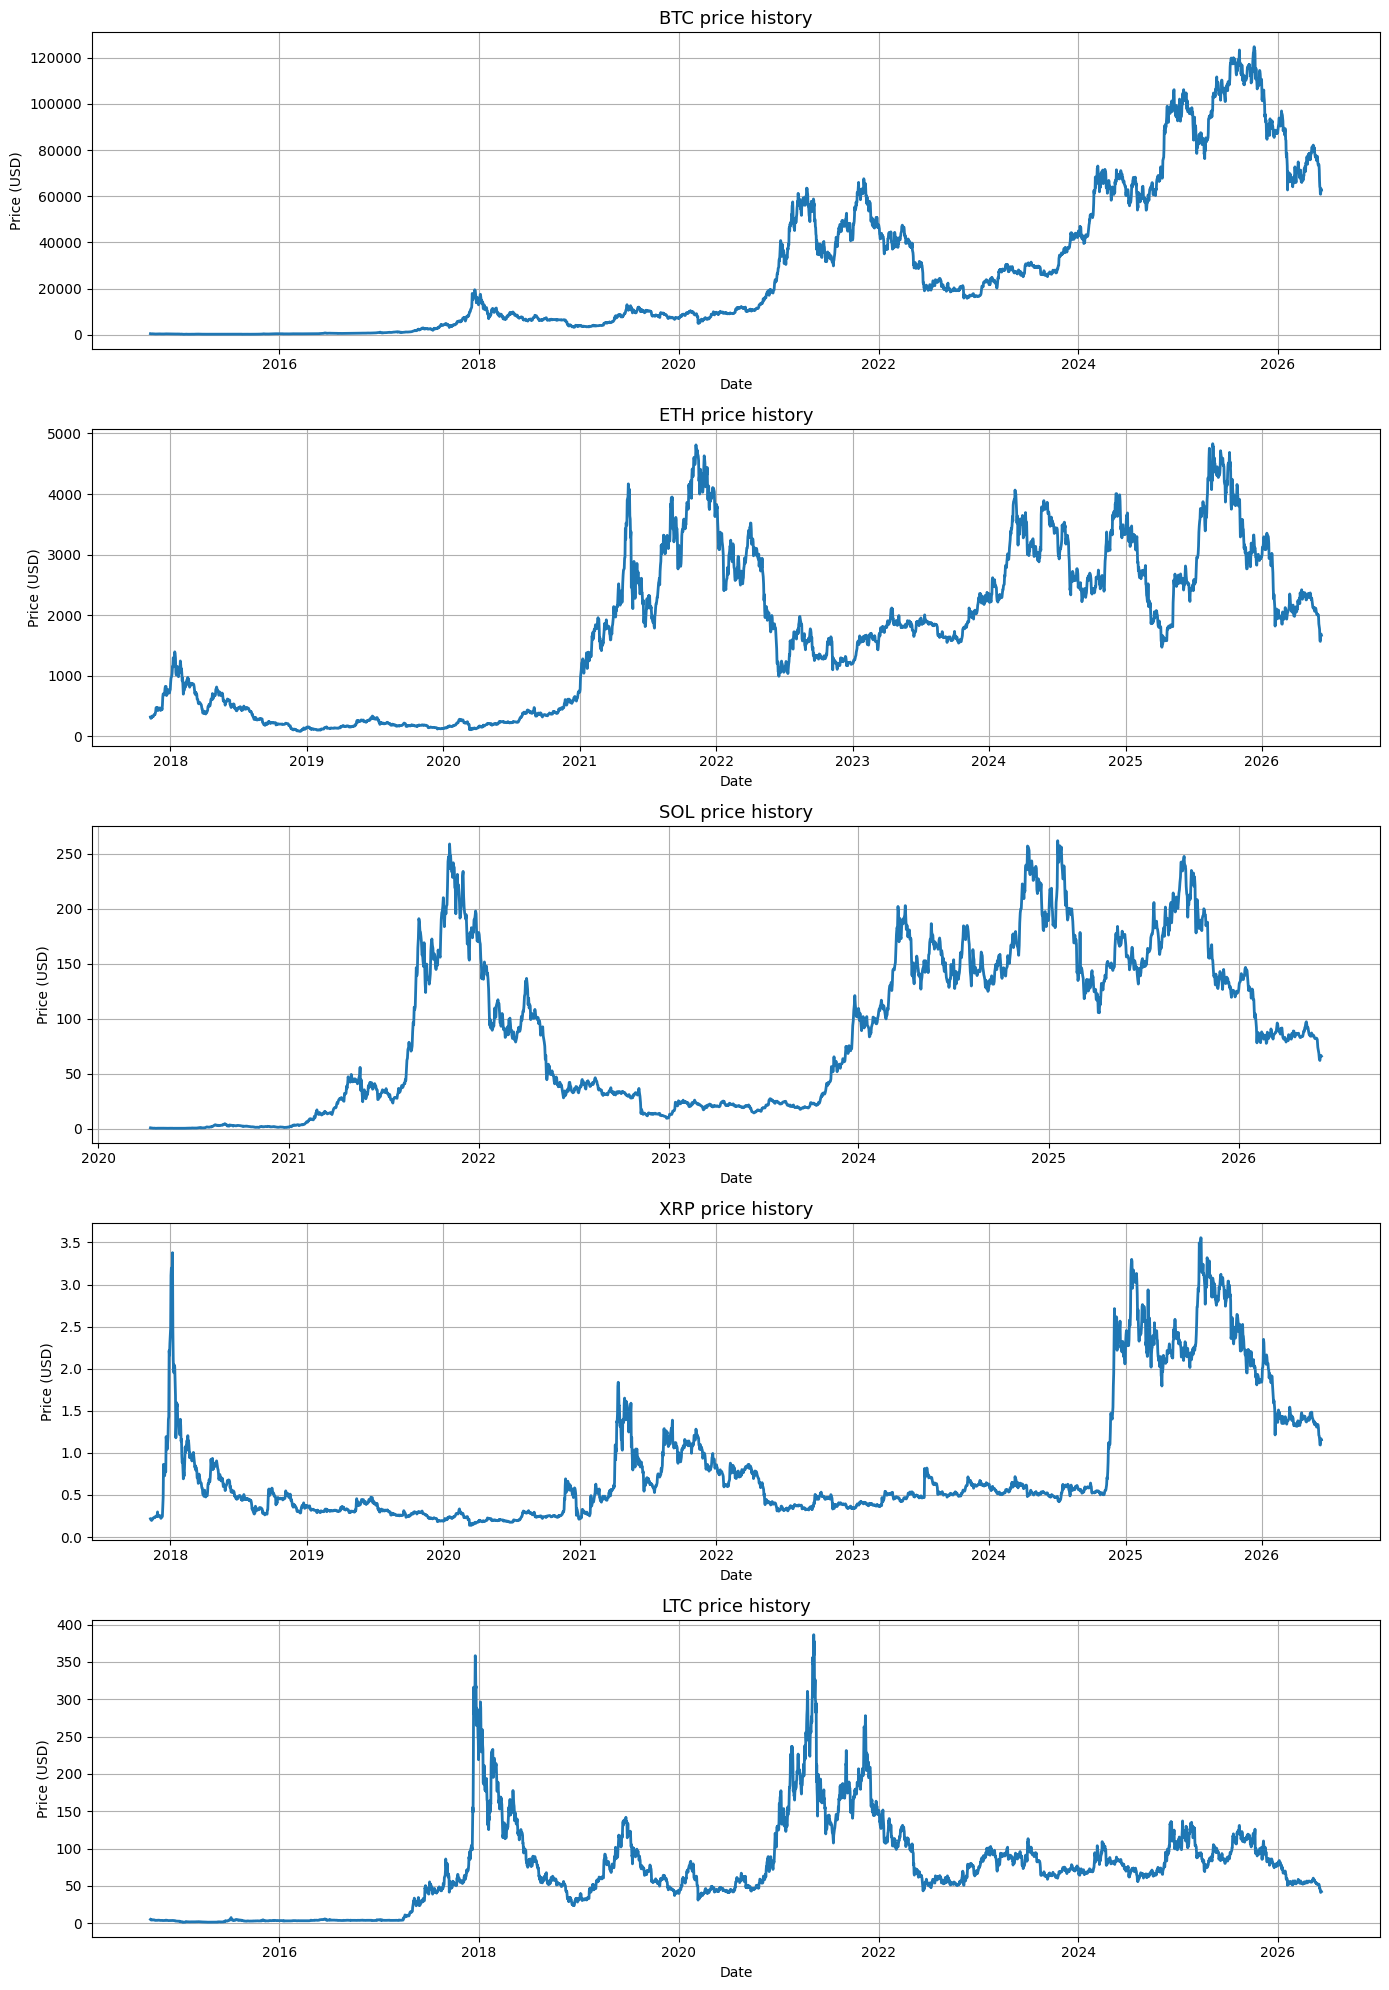

In [7]:
import matplotlib.pyplot as plt


fig,axes = plt.subplots(len(dataframe),1, figsize = (14, 4 * len(dataframe)))
for ax,(symbol,df) in zip(axes, dataframe.items()):
  ax.plot(df.index, df["price"], linewidth = 2)
  ax.set_title(f'{symbol.upper()} price history',fontsize = 13)
  ax.set_xlabel("Date")
  ax.set_ylabel("Price (USD)")
  ax.grid(True)
plt.tight_layout()
plt.show()


In [8]:
def split_data(df, symbol, split_ratio = 0.8):
  split_index = int(len(df) * split_ratio)
  train = df[:split_index]
  test = df[split_index:]
  print(f"{symbol.upper()} — Train: {len(train)} rows ({train.index.min().date()} → {train.index.max().date()})")
  print(f"{symbol.upper()} — Test:  {len(test)} rows ({test.index.min().date()} → {test.index.max().date()})")

  return train, test

In [9]:
splits = {}

for symbol,df in dataframe.items():
  train,test = split_data(df,symbol)
  splits[symbol] = {"train" : train, "test" : test}

BTC — Train: 3427 rows (2014-09-17 → 2024-02-03)
BTC — Test:  857 rows (2024-02-04 → 2026-06-09)
ETH — Train: 2508 rows (2017-11-09 → 2024-09-20)
ETH — Test:  627 rows (2024-09-21 → 2026-06-09)
SOL — Train: 1801 rows (2020-04-10 → 2025-03-15)
SOL — Test:  451 rows (2025-03-16 → 2026-06-09)
XRP — Train: 2508 rows (2017-11-09 → 2024-09-20)
XRP — Test:  627 rows (2024-09-21 → 2026-06-09)
LTC — Train: 3427 rows (2014-09-17 → 2024-02-03)
LTC — Test:  857 rows (2024-02-04 → 2026-06-09)


In [10]:
#This cell is only for the LSTM model, Since LSTM model can only work well with values between 0 and 1, So this is for normalising the values of the crypto currency price
from sklearn.preprocessing import MinMaxScaler
scalers = {}
for symbol in dataframe:
  train =  splits[symbol]["train"]
  test = splits[symbol]["test"]
  scaler = MinMaxScaler()

  train_scaled = scaler.fit_transform(train[["price"]])
  test_scaled = scaler.transform(test[["price"]])
  scalers[symbol] = scaler
  splits[symbol]["train_scaled"] = train_scaled
  splits[symbol]["test_scaled"]  = test_scaled

  print(f"{symbol.upper()} — min: ${train['price'].min():.2f}  max: ${train['price'].max():.2f}  → normalized to [0, 1]")



BTC — min: $178.10  max: $67566.83  → normalized to [0, 1]
ETH — min: $84.31  max: $4812.09  → normalized to [0, 1]
SOL — min: $0.52  max: $261.87  → normalized to [0, 1]
XRP — min: $0.14  max: $3.38  → normalized to [0, 1]
LTC — min: $1.16  max: $386.45  → normalized to [0, 1]


In [11]:
#Verify if the scaled values exists
for symbol in splits:
    print(f"{symbol.upper()} — train_scaled shape: {splits[symbol]['train_scaled'].shape}")
    print(f"{symbol.upper()} — test_scaled shape:  {splits[symbol]['test_scaled'].shape}")
    print()

BTC — train_scaled shape: (3427, 1)
BTC — test_scaled shape:  (857, 1)

ETH — train_scaled shape: (2508, 1)
ETH — test_scaled shape:  (627, 1)

SOL — train_scaled shape: (1801, 1)
SOL — test_scaled shape:  (451, 1)

XRP — train_scaled shape: (2508, 1)
XRP — test_scaled shape:  (627, 1)

LTC — train_scaled shape: (3427, 1)
LTC — test_scaled shape:  (857, 1)



In [12]:
from scipy.stats import alpha
!pip install statsmodels -q
#Importing the 4 required statistical models
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import numpy as np

#the function is going to used to evalute the model and plot
def eval_model(symbol, test, prediction, model_name):
  rmse =  np.sqrt(mean_squared_error(test, prediction))
  plt.plot(test.index, test["price"] ,label = "Actual", color = "blue", linewidth = 1)
  plt.plot(test.index, prediction, label = f"{model_name} prediction", color = "red", linewidth = 1)
  plt.title(f"{symbol.upper()} — {model_name} (RMSE: ${rmse:.2f})")
  plt.xlabel("Date")
  plt.ylabel("Price (USD)")
  plt.legend()
  plt.grid(True, alpha = 0.3)
  plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %Y"))
  plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=2))
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()
  print(f"{symbol.upper()}: {model_name} model: RMSE: ${rmse:.2f}")
  return rmse


##1.Simple Exponential Smoothing
SES predicts the next value as a weighted average of all past values - recent prices get more weight, older prices get less. It's the simplest of the 4 models.

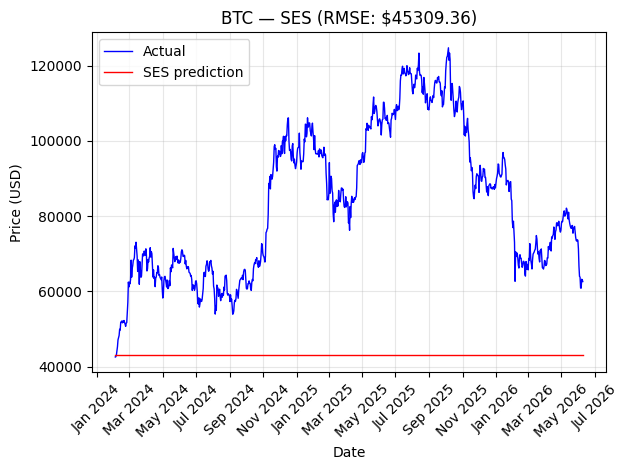

BTC: SES model: RMSE: $45309.36


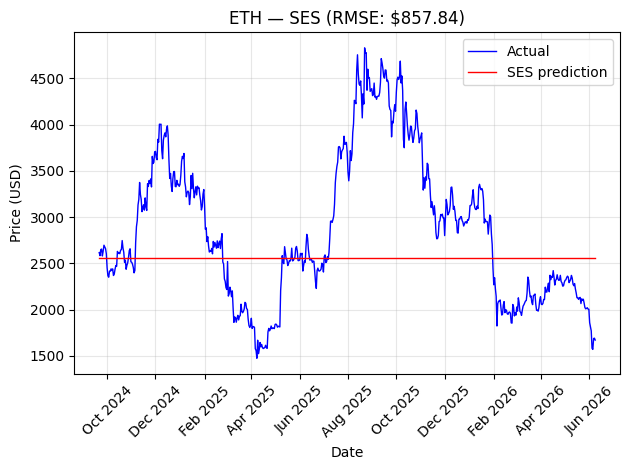

ETH: SES model: RMSE: $857.84


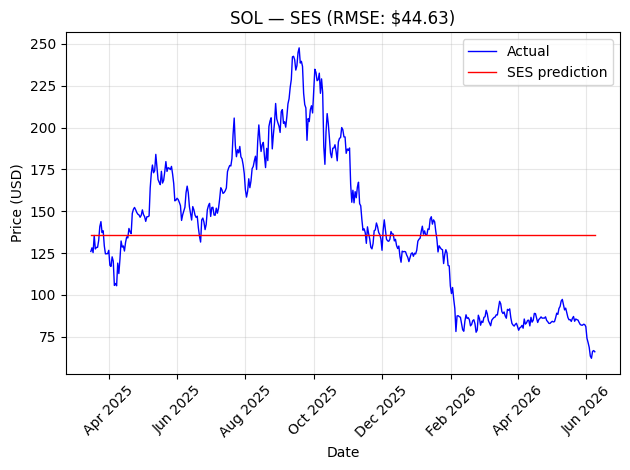

SOL: SES model: RMSE: $44.63


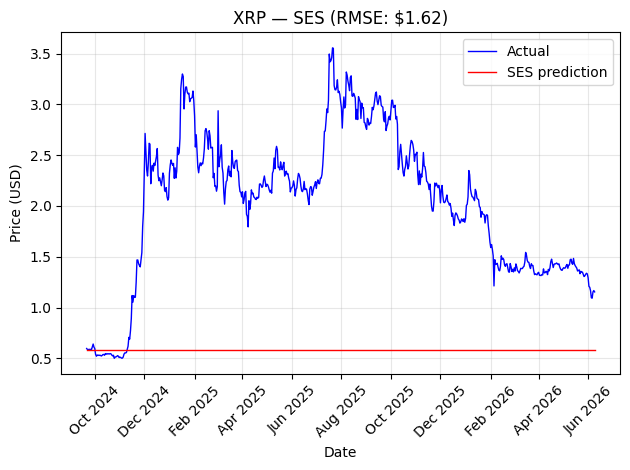

XRP: SES model: RMSE: $1.62


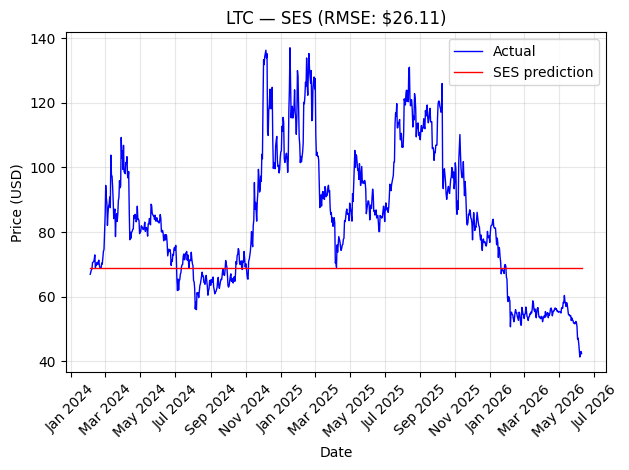

LTC: SES model: RMSE: $26.11
RMSE for SES
BTC: 45309.356265657
ETH: 857.8358932335537
SOL: 44.63249732015189
XRP: 1.6174152323132507
LTC: 26.109682304853


In [25]:
ses_results = {}
ses_pred = {}
for symbol in splits:
  train = splits[symbol]["train"]
  test = splits[symbol]["test"]
  model = SimpleExpSmoothing(train["price"])
  model_fit = model.fit(optimized = True)
  prediction = model_fit.forecast(steps = len(test))
  prediction.index =  test.index

  rmse = eval_model(symbol, test, prediction, "SES")
  ses_results[symbol] = rmse
  ses_pred[symbol] = prediction
print("RMSE for SES")
for s,er in ses_results.items():
  print(f'{s.upper()}: {er}')

##2. HWES (Holt-Winters Exponential Smoothing)
SES only learns the level of the series. HWES adds two more components: trend + seasonality
So it actually captures the direction prices are moving and repeating cycles much better than a flat line.



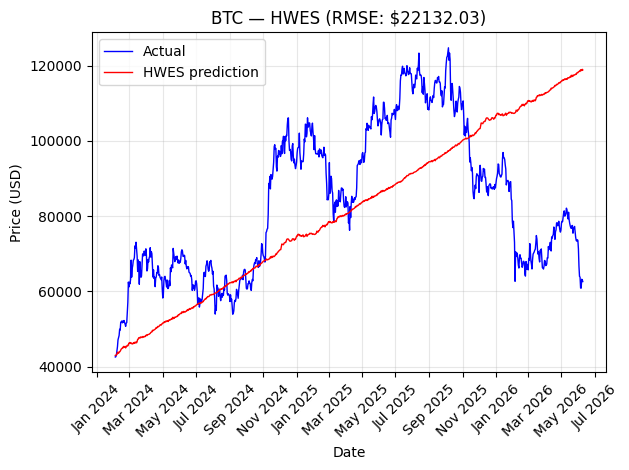

BTC: HWES model: RMSE: $22132.03


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


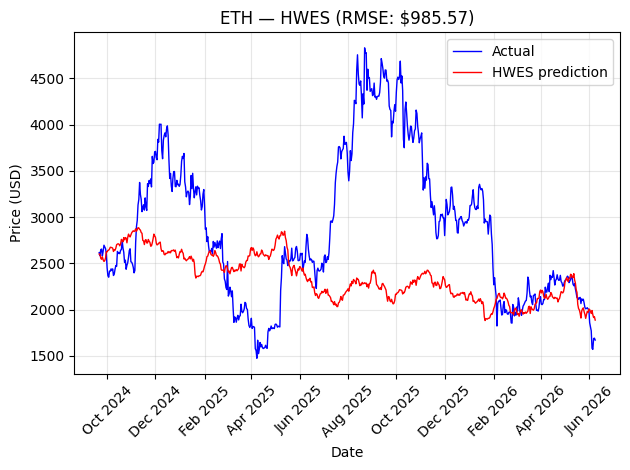

ETH: HWES model: RMSE: $985.57


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


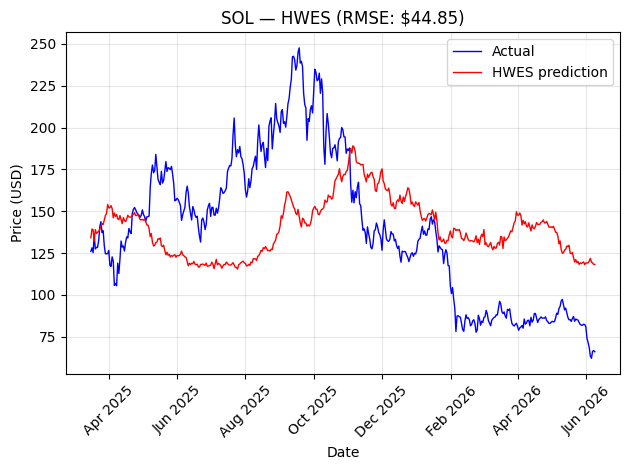

SOL: HWES model: RMSE: $44.85


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


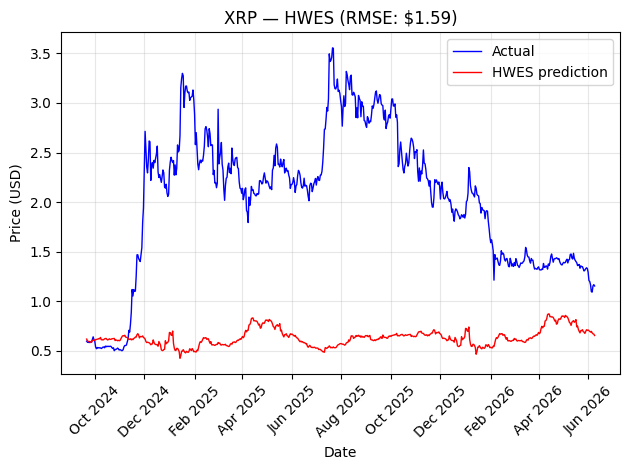

XRP: HWES model: RMSE: $1.59


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


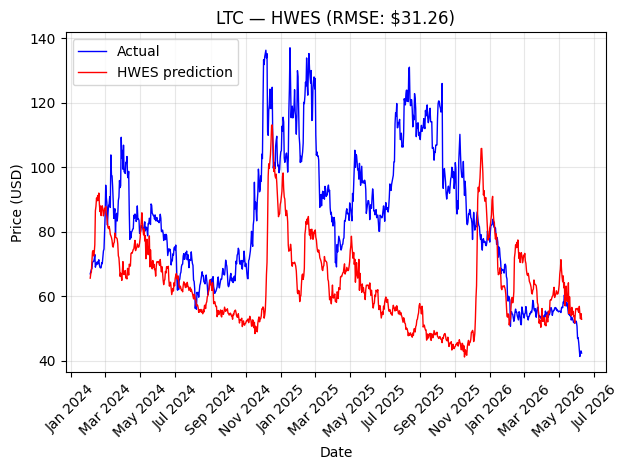

LTC: HWES model: RMSE: $31.26
RMSE for HWES
BTC: 22132.026441404003
ETH: 985.573970982775
SOL: 44.84744479758115
XRP: 1.5866585249469582
LTC: 31.263396100356818


In [27]:
hwes_results = {}
hwes_pred = {}
for symbol in splits:
  train = splits[symbol]["train"]
  test = splits[symbol]["test"]
  model = ExponentialSmoothing(
      train["price"],
      trend = "add",
      seasonal = "add",
      seasonal_periods = 365)
  model_fit = model.fit(optimized = True)
  prediction = model_fit.forecast(steps = len(test))
  prediction.index =  test.index
  hwes_pred[symbol] = prediction
  rmse = eval_model(symbol, test, prediction, "HWES")
  hwes_results[symbol] = rmse
print("RMSE for HWES")
for s,e in hwes_results.items():
  print(f'{s.upper()}: {e}')

##ARIMA(Auto Regressive Integrated Moving Average)
ARIMA is a widely used technique in time series analysis that combines three key components: autoregression (AR), differencing (I), and moving average (MA) to model and predict future values based on past observations .It is particularly useful for data that shows trends or non-stationary behavior, where the mean and variance change over time.


Training ARIMA for BTC...


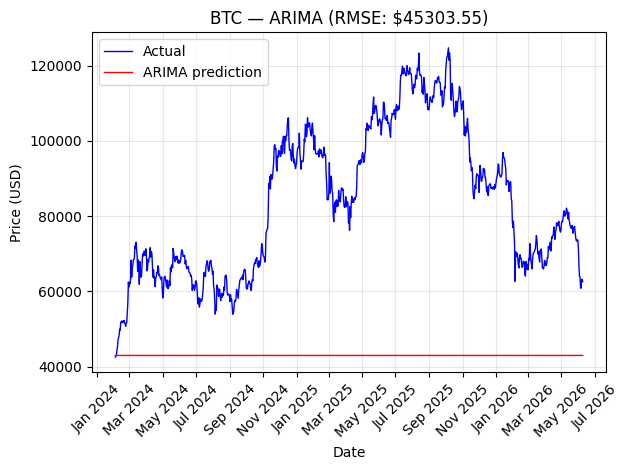

BTC: ARIMA model: RMSE: $45303.55
Training ARIMA for ETH...


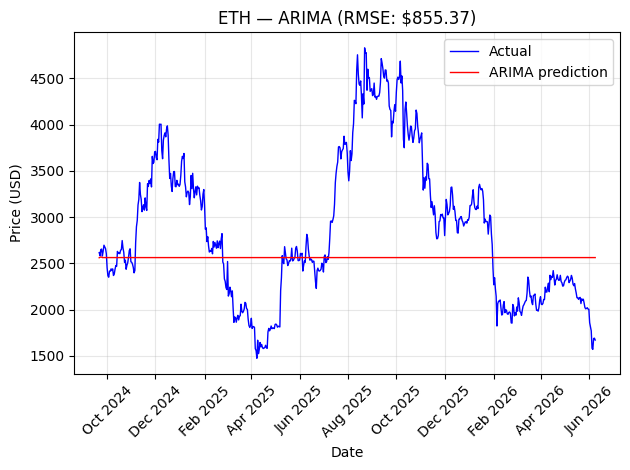

ETH: ARIMA model: RMSE: $855.37
Training ARIMA for SOL...


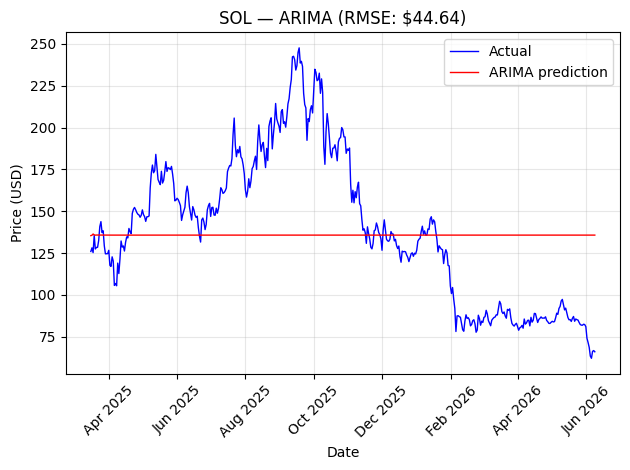

SOL: ARIMA model: RMSE: $44.64
Training ARIMA for XRP...


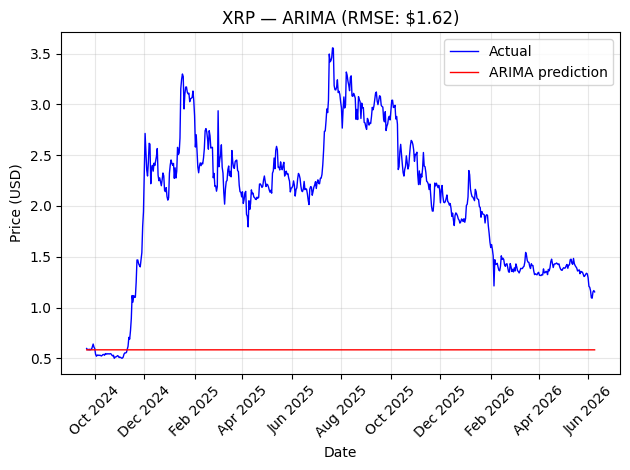

XRP: ARIMA model: RMSE: $1.62
Training ARIMA for LTC...


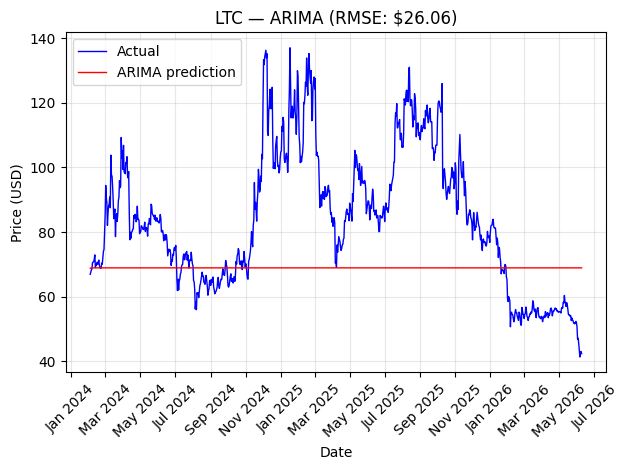

LTC: ARIMA model: RMSE: $26.06
RMSE for ARIMA
BTC: 45303.55399707513
ETH: 855.3748628507749
SOL: 44.64244168927512
XRP: 1.6175468657018794
LTC: 26.056766657040896


In [28]:
arima_results = {}
arima_pred = {}
for symbol in splits:
  train = splits[symbol]["train"]
  test = splits[symbol]["test"]
  print(f"Training ARIMA for {symbol.upper()}...")

  model = ARIMA(train["price"], order=(5, 1, 0))
  fitted = model.fit()

  predictions = fitted.forecast(steps=len(test))
  predictions.index = test.index
  arima_pred[symbol] = predictions
  rmse = eval_model(symbol, test, predictions, "ARIMA")
  arima_results[symbol] = rmse
print("RMSE for ARIMA")
for s,er in arima_results.items():
  print(f'{s.upper()}: {er}')


ARIMA's weakness here is that it's forecasting hundreds of days ahead in one shot, it quickly loses track and reverts to a trend line, similar to SES.

Training SARIMA for BTC...


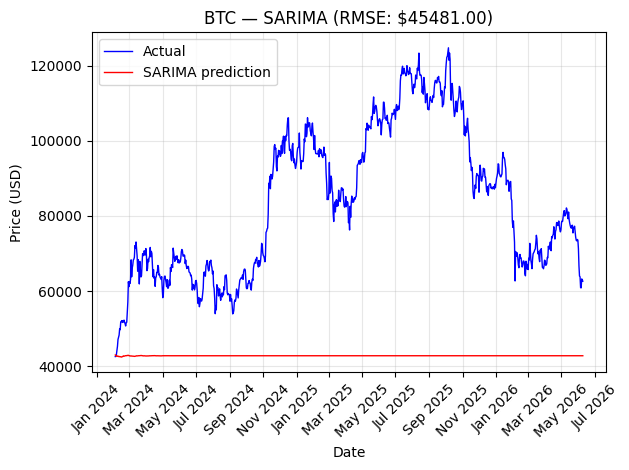

BTC: SARIMA model: RMSE: $45481.00
Training SARIMA for ETH...


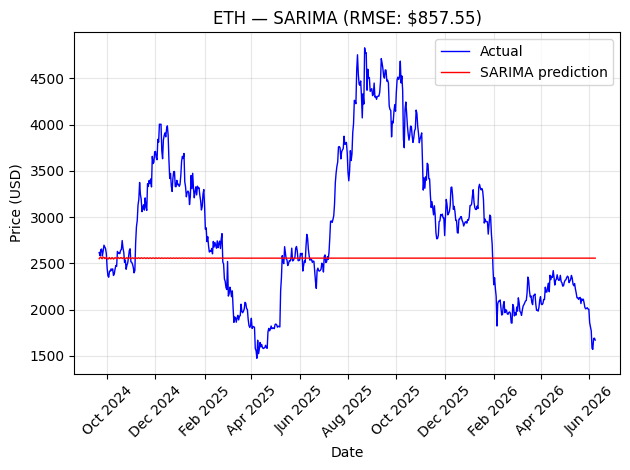

ETH: SARIMA model: RMSE: $857.55
Training SARIMA for SOL...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


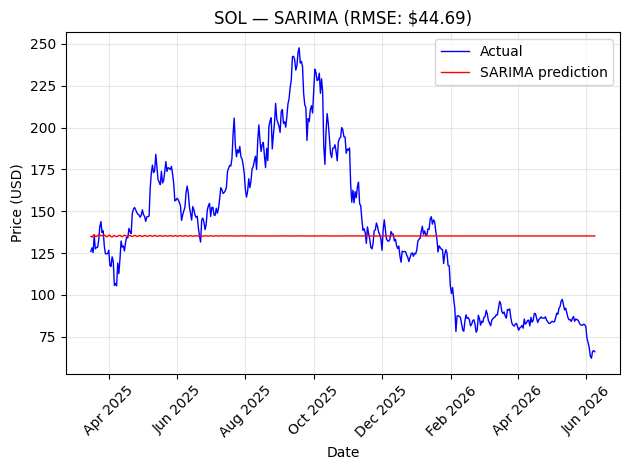

SOL: SARIMA model: RMSE: $44.69
Training SARIMA for XRP...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


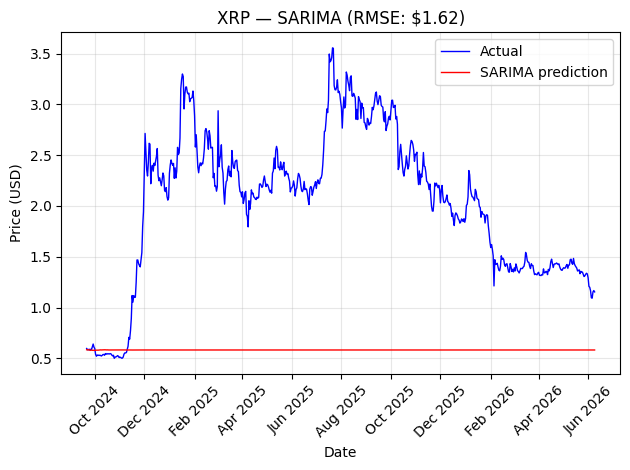

XRP: SARIMA model: RMSE: $1.62
Training SARIMA for LTC...


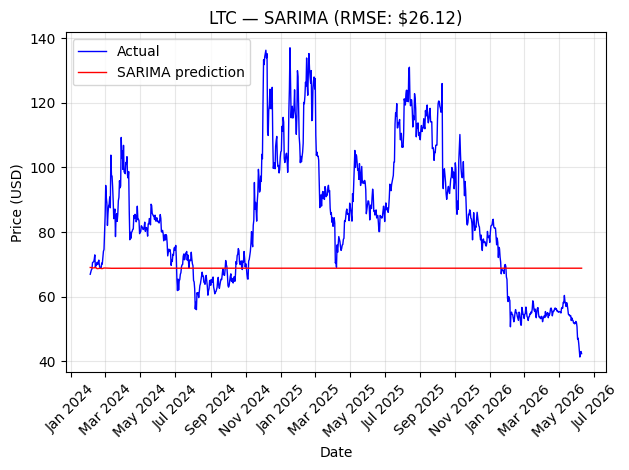

LTC: SARIMA model: RMSE: $26.12
RMSE for SARIMA
BTC: 45481.00498276322
ETH: 857.5506206467381
SOL: 44.68905171141738
XRP: 1.6188936166295256
LTC: 26.117541802146324


In [29]:
sarima_results = {}
sarima_pred = {}
for symbol in splits:
  train = splits[symbol]["train"]
  test = splits[symbol]["test"]

  print(f"Training SARIMA for {symbol.upper()}...")
  model = SARIMAX(
      train["price"],
      order=(2, 1, 2),
      seasonal_order=(1, 0, 1, 12)

  )
  model_fit = model.fit(disp=0)
  prediction = model_fit.forecast(steps = len(test))
  prediction.index =  test.index
  sarima_pred[symbol] = prediction
  rmse = eval_model(symbol, test, prediction, "SARIMA")
  sarima_results[symbol] = rmse
print("RMSE for SARIMA")
for s,er in sarima_results.items():
  print(f'{s.upper()}: {er}')


### Observation
SARIMA performed similarly to SES on long-horizon forecasts.
This is expected - SARIMA is designed for short-term forecasting (weeks, not years).
The real improvement will come from LSTM in Phase 5, which is built
specifically for learning long-term patterns in sequential data.

In [17]:
results = {
    "SES":    ses_results,
    "HWES":   hwes_results,
    "ARIMA":  arima_results,
    "SARIMA": sarima_results
}
print(results)

results_df = pd.DataFrame(results)
results_df.index=[s.upper() for s in splits.keys()]
results_df = results_df.round(2)
print(results_df)

{'SES': {'btc': np.float64(45309.356265657), 'eth': np.float64(857.8358932335537), 'sol': np.float64(44.63249732015189), 'xrp': np.float64(1.6174152323132507), 'ltc': np.float64(26.109682304853)}, 'HWES': {'btc': np.float64(22132.026441404003), 'eth': np.float64(985.573970982775), 'sol': np.float64(44.84744479758115), 'xrp': np.float64(1.5866585249469582), 'ltc': np.float64(31.263396100356818)}, 'ARIMA': {'btc': np.float64(45303.55399707513), 'eth': np.float64(855.3748628507749), 'sol': np.float64(44.64244168927512), 'xrp': np.float64(1.6175468657018794), 'ltc': np.float64(26.056766657040896)}, 'SARIMA': {'btc': np.float64(45481.00498276322), 'eth': np.float64(857.5506206467381), 'sol': np.float64(44.68905171141738), 'xrp': np.float64(1.6188936166295256), 'ltc': np.float64(26.117541802146324)}}
          SES      HWES     ARIMA    SARIMA
BTC  45309.36  22132.03  45303.55  45481.00
ETH    857.84    985.57    855.37    857.55
SOL     44.63     44.85     44.64     44.69
XRP      1.62     

##LSTM(Long Short Term Memory)
The statistical models (SES, HWES, ARIMA, SARIMA) all assume prices follow a fixed mathematical formula. LSTM doesn't assume anything, it learns patterns directly from the data.
a type of neural network designed specifically for sequences. It has a "memory" that decides what to remember and what to forget as it reads through price history. For statistical model we define formula and model fits to paraameters.
But LSTM it takes the data and learn to make formula itself. To train it we need normalized values thats why we normalized earlier.

In [18]:
def create_seq(data, window=60):
  x,y = [],[]
  for i in range(window, len(data)):
    x.append(data[i-window:i,0])
    y.append(data[i,0])
  return np.array(x), np.array(y)
seq = {}
WINDOW = 60
for symbol in splits:
  train_scaled = splits[symbol]["train_scaled"]
  test_scaled = splits[symbol]["test_scaled"]

  x_train,y_train = create_seq(train_scaled, WINDOW)
  test_data = np.concatenate([train_scaled[-WINDOW:], test_scaled])
  x_test,y_test = create_seq(test_data, WINDOW)
  seq[symbol] = {
        "x_train": x_train,
        "y_train": y_train,
        "x_test":  x_test,
        "y_test":  y_test
    }

  print(f"{symbol.upper()} — X_train: {x_train.shape}  X_test: {x_test.shape}")



BTC — X_train: (3367, 60)  X_test: (857, 60)
ETH — X_train: (2448, 60)  X_test: (627, 60)
SOL — X_train: (1741, 60)  X_test: (451, 60)
XRP — X_train: (2448, 60)  X_test: (627, 60)
LTC — X_train: (3367, 60)  X_test: (857, 60)


In [19]:
from scipy.optimize._lsq.trf import build_quadratic_1d
#This is where we are going to build out LSTM model

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

def build_lstm(window = 60):
  model = Sequential([
      LSTM(100, return_sequences = True, input_shape = (window, 1)),
      Dropout(0.2),
      LSTM(50, return_sequences = False),
      Dropout(0.2),
      Dense(1),
  ])
  model.compile(optimizer = "adam", loss="mean_squared_error")
  return model
model_preview = build_lstm(WINDOW)
model_preview.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
from sklearn.utils import validation
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint
lstm_models = {}
lstm_history = {}
for symbol in seq:
  print(f"\nTraining LSTM for {symbol.upper()}...")
  x_train = seq[symbol]["x_train"].reshape(-1,WINDOW,1)
  y_train = seq[symbol]["y_train"]
  model = build_lstm(WINDOW)
  os.makedirs("models",exist_ok=True)
  callbacks = [
      EarlyStopping(monitor="val_loss", patience=5, restore_best_weights= True),
      ModelCheckpoint(f"models/lstm_{symbol}.keras", save_best_only = True)
  ]
  history = model.fit(
      x_train,
      y_train,
      batch_size = 32,
      epochs = 50,
      validation_split= 0.1,
      callbacks = callbacks,
      verbose = 0
  )
  lstm_models[symbol] = model
  lstm_history[symbol] = history
  print(f"{symbol.upper()}: training done!")




Training LSTM for BTC...
BTC: training done!

Training LSTM for ETH...
ETH: training done!

Training LSTM for SOL...
SOL: training done!

Training LSTM for XRP...
XRP: training done!

Training LSTM for LTC...
LTC: training done!


27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


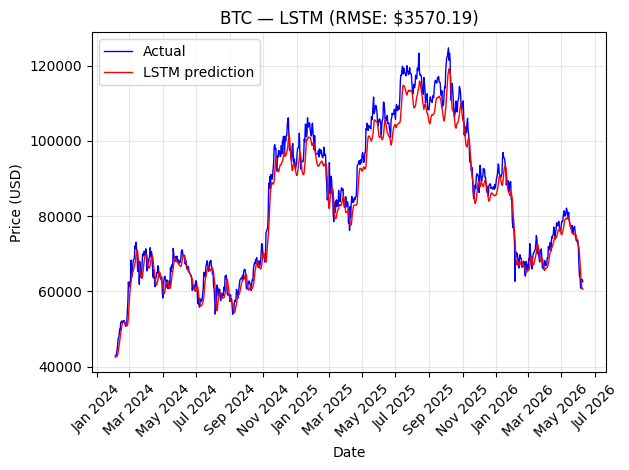

BTC: LSTM model: RMSE: $3570.19
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


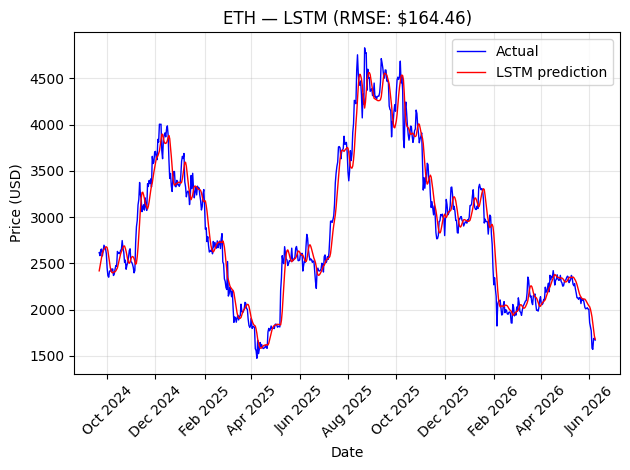

ETH: LSTM model: RMSE: $164.46
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


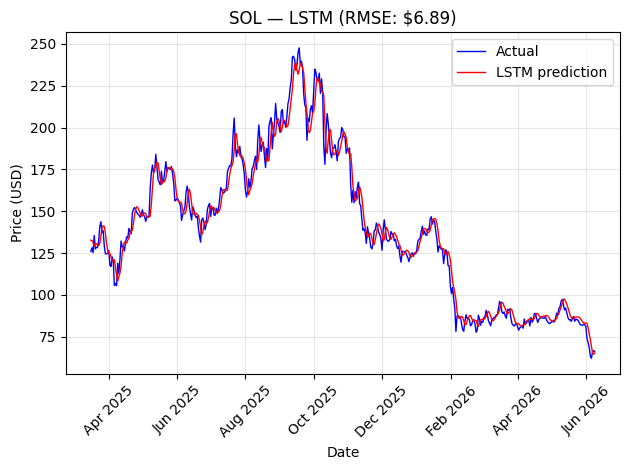

SOL: LSTM model: RMSE: $6.89
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


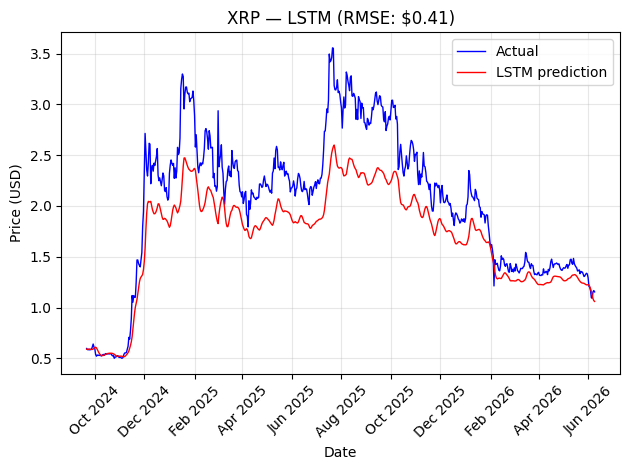

XRP: LSTM model: RMSE: $0.41
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


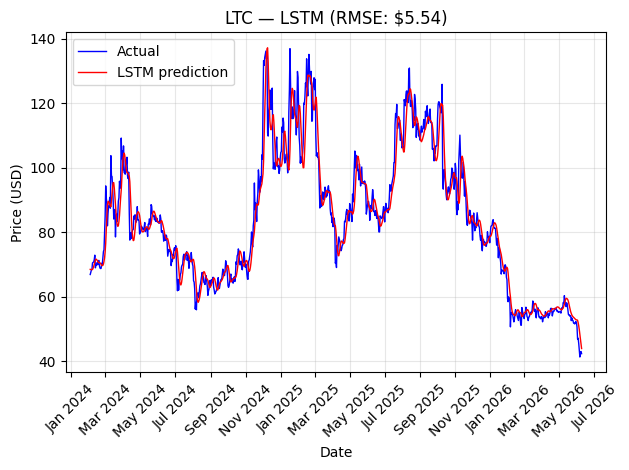

LTC: LSTM model: RMSE: $5.54
RMSE for LSTM
BTC: 3570.1932720792583
ETH: 164.46354554277372
SOL: 6.888046093457542
XRP: 0.41403536437745225
LTC: 5.540908914640431


In [30]:
lstm_results = {}
lstm_pred = {}
for symbol in seq:
  x_test = seq[symbol]["x_test"].reshape(-1,WINDOW,1)
  y_test = seq[symbol]["y_test"]

  prediction_scaled = lstm_models[symbol].predict(x_test)
  prediction = scalers[symbol].inverse_transform(prediction_scaled)
  actual = scalers[symbol].inverse_transform(y_test.reshape(-1, 1))

  test_index = splits[symbol]["test"].index
  prediction_series = pd.Series(prediction.flatten(), index = test_index)
  actual_series = pd.Series(actual.flatten(), index = test_index)

  lstm_pred[symbol] = prediction_series
  rmse = eval_model(symbol, pd.DataFrame({"price":actual_series}), prediction_series, "LSTM")
  lstm_results[symbol] = rmse
print("RMSE for LSTM")
for s,er in lstm_results.items():
  print(f'{s.upper()}: {er}')

In [24]:
results = {
    "SES":    ses_results,
    "HWES":   hwes_results,
    "ARIMA":  arima_results,
    "SARIMA": sarima_results,
    "LSTM":   lstm_results
}

results_df = pd.DataFrame(results)
results_df.index=[s.upper() for s in splits.keys()]
results_df = results_df.round(2)


print("=== RMSE Comparison (lower is better) ===\n")
print(results_df.to_string())

print("\n=== Best model per coin ===")
for coin in results_df.index:
    best_model = results_df.loc[coin].idxmin()
    best_rmse  = results_df.loc[coin].min()
    print(f"{coin}: {best_model} (RMSE: ${best_rmse:.2f})")

=== RMSE Comparison (lower is better) ===

          SES      HWES     ARIMA    SARIMA     LSTM
BTC  45309.36  22132.03  45303.55  45481.00  3570.19
ETH    857.84    985.57    855.37    857.55   164.46
SOL     44.63     44.85     44.64     44.69     6.89
XRP      1.62      1.59      1.62      1.62     0.41
LTC     26.11     31.26     26.06     26.12     5.54

=== Best model per coin ===
BTC: LSTM (RMSE: $3570.19)
ETH: LSTM (RMSE: $164.46)
SOL: LSTM (RMSE: $6.89)
XRP: LSTM (RMSE: $0.41)
LTC: LSTM (RMSE: $5.54)


In [31]:
pred_dict = {}
for symbol in splits:
  pred_dict[symbol]={
      "SES": ses_pred[symbol],
      "HWES": hwes_pred[symbol],
      "ARIMA": arima_pred[symbol],
      "SARIMA": sarima_pred[symbol],
      "LSTM": lstm_pred[symbol]
  }



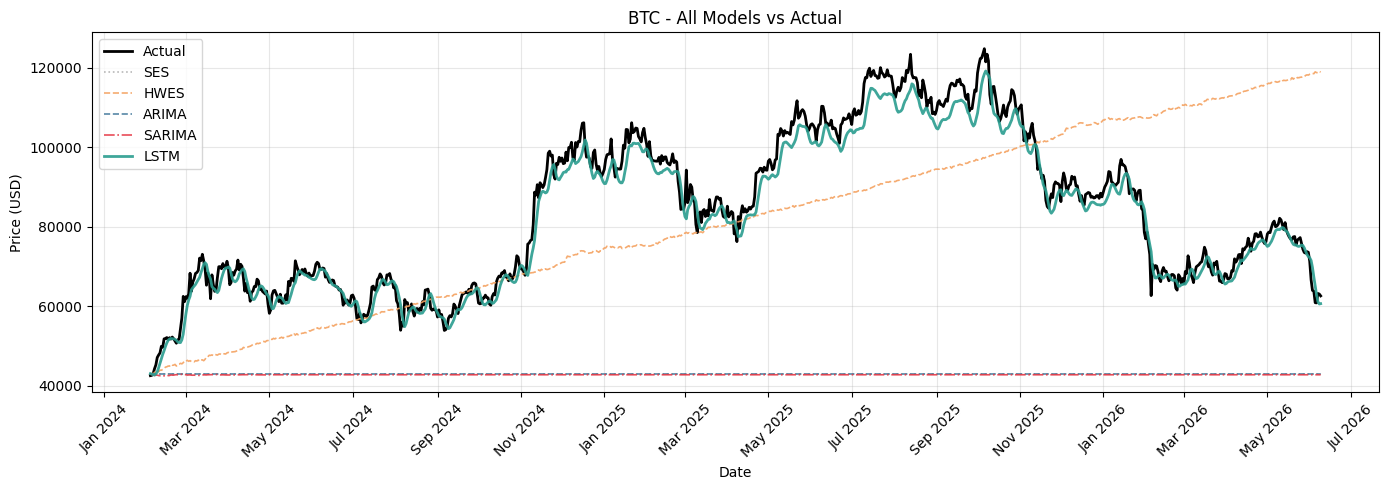

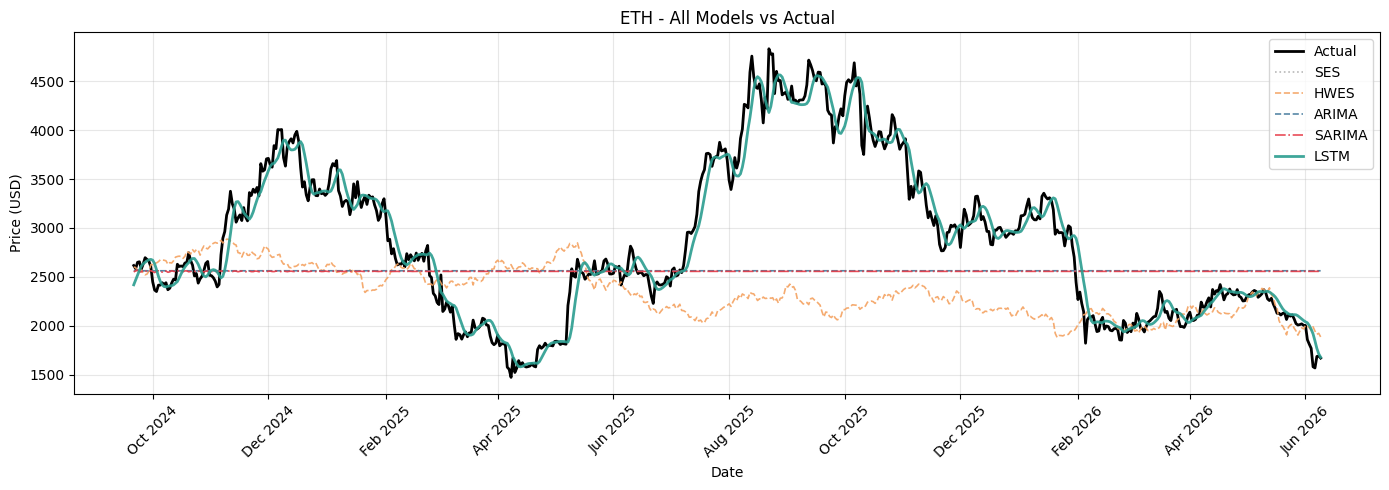

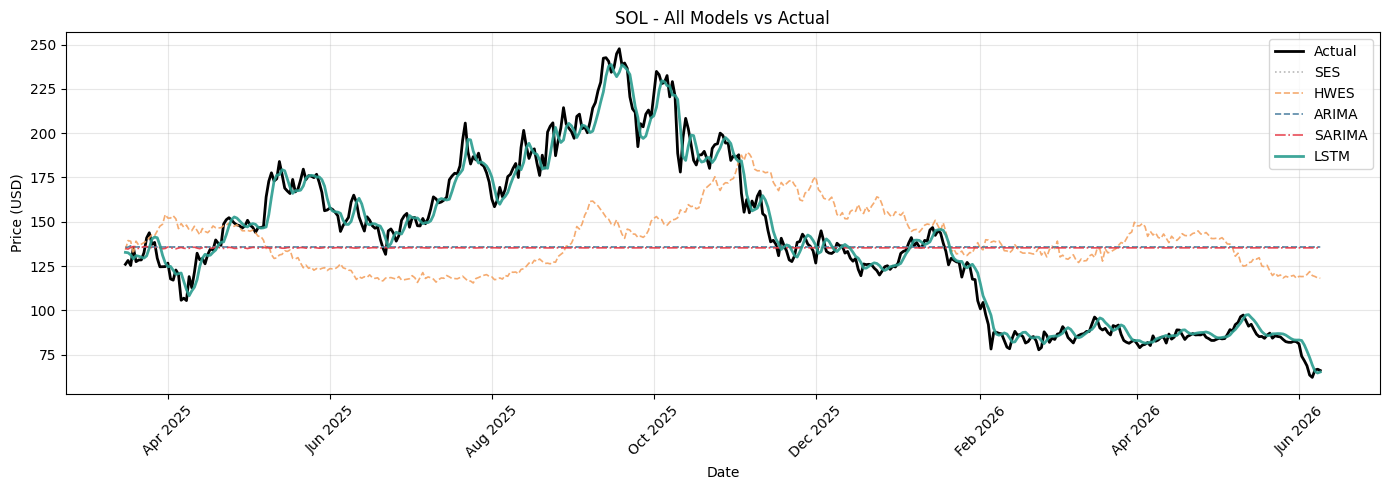

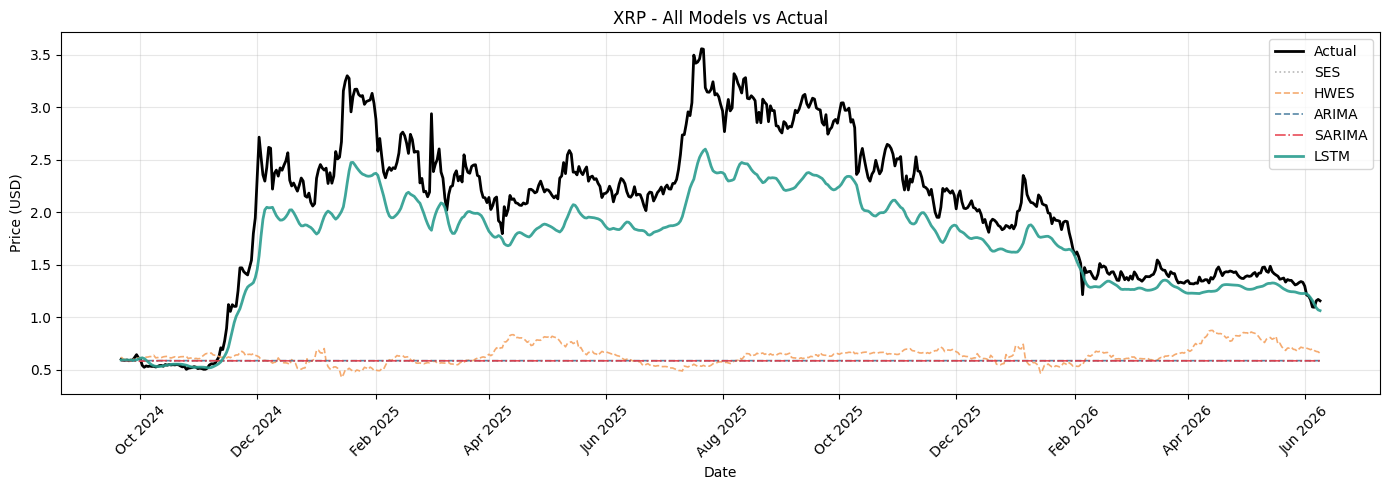

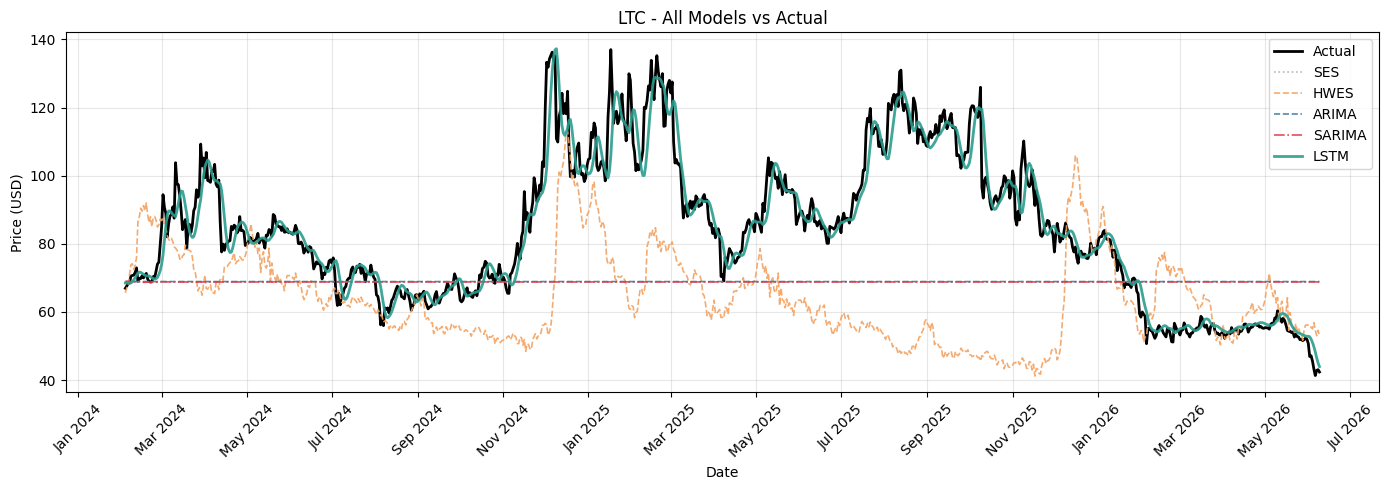

In [34]:
#The final plots to show which model is best for predicting the crypto price
model_styles = {
    "SES":    {"color": "#b0b0b0", "linestyle": "dotted",  "linewidth": 1.2},
    "HWES":   {"color": "#f4a261", "linestyle": "dashed",  "linewidth": 1.2},
    "ARIMA":  {"color": "#457b9d", "linestyle": "dashed",  "linewidth": 1.2},
    "SARIMA": {"color": "#e63946", "linestyle": "dashdot", "linewidth": 1.2},
    "LSTM":   {"color": "#2a9d8f", "linestyle": "solid",   "linewidth": 2},
}

for symbol in pred_dict:
    test = splits[symbol]["test"]

    plt.figure(figsize=(14, 5))
    plt.plot(test.index, test["price"],
             label="Actual", color="black", linewidth=2)

    for model_name, style in model_styles.items():
        plt.plot(test.index, pred_dict[symbol][model_name],
                 label=model_name,
                 color=style["color"],
                 linestyle=style["linestyle"],
                 linewidth=style["linewidth"],
                 alpha=0.9)

    plt.title(f"{symbol.upper()} - All Models vs Actual")
    plt.xlabel("Date")
    plt.ylabel("Price (USD)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %Y"))
    plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=2))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Conclusion

This project compared five forecasting models on historical price data
for BTC, ETH, SOL, XRP and LTC.

### Key findings
- **HWES** performed best among statistical models, successfully capturing
  trend and seasonality
- **LSTM** outperformed all statistical models by learning long-term patterns
  directly from data
- **SES, ARIMA, SARIMA** struggled with long-horizon forecasts (600-800 days),
  reverting to flat or mean lines — expected behavior for these models
- Statistical models are better suited for **short-term forecasting** (7-30 days)
- LSTM is better suited for **long-term forecasting** on sequential data

### Limitations
- CoinGecko/Yahoo Finance data does not include market sentiment, news,
  or social media signals which heavily influence crypto prices
- Models are retrained on historical data only — real-time retraining
  would improve accuracy

### Future improvements
- Add sentiment analysis from Twitter/Reddit
- Try Transformer-based models (better than LSTM for very long sequences)
- Build a live dashboard that retrains daily with fresh data